## Stats Analysis

### Set up

In [19]:
import pandas as pd

RUNS = list(range(1, 6))
ALL_VARS = list(range(2, 17))
BASE_PATH = "../statistics"

INVERSION_THRESHOLD = 0.1
WASSERSTEIN_THRESHOLD = 0.15
RECONSTRUCTION_THRESHOLD = 2
CCC_THRESHOLD = 0.9

### Base models

In [ ]:
df_inversion_ratios = pd.read_csv(f"{BASE_PATH}/inversion_ratios.csv")
df_reconstruction_rmsd = pd.read_csv(f"{BASE_PATH}/reconstruction_rmsd.csv")
df_wasserstein_distances = pd.read_csv(f"{BASE_PATH}/wasserstein_distances.csv")
df_pairwise_rmsd_ccc = pd.read_csv(f"{BASE_PATH}/pairwise_rmsd_ccc.csv")


# Filter wasserstein to N-CA only, then drop bond_type
df_wd = df_wasserstein_distances.query("bond_type == 'N-CA'").drop(columns="bond_type")

# Rename mean/std columns to be unique before merging
df_rmsd = df_reconstruction_rmsd.rename(
    columns={"mean": "rmsd_mean", "std": "rmsd_std"}
)
df_wd = df_wd.rename(columns={"mean": "wd_mean", "std": "wd_std"})
df_ccc = df_pairwise_rmsd_ccc.rename(columns={"mean": "ccc_mean", "std": "ccc_std"})

# Merge all on (var, dataset)
df_all = (
    df_rmsd.merge(df_inversion_ratios, on=["var", "dataset"])
    .merge(df_wd, on=["var", "dataset"])
    .merge(df_ccc, on=["var", "dataset"])
    .sort_values(["var", "dataset"])
    .reset_index(drop=True)
)

print("here")


def style_table(df_split: pd.DataFrame, title: str):
    metric_cols = [
        "rmsd_mean",
        "rmsd_std",
        "inversion_mean",
        "inversion_std",
        "wd_mean",
        "wd_std",
        "ccc_mean",
        "ccc_std",
    ]
    target = df_split.set_index("var")[metric_cols]

    def highlight(val, col):
        if col == "rmsd_mean" and val > RECONSTRUCTION_THRESHOLD:
            return "background-color: #f4cccc"
        if col == "inversion_mean" and val < INVERSION_THRESHOLD:
            return "background-color: #f4cccc"
        if col == "wd_mean" and val > WASSERSTEIN_THRESHOLD:
            return "background-color: #f4cccc"
        if col == "ccc_mean" and val < CCC_THRESHOLD:
            return "background-color: #f4cccc"
        return ""

    styled = target.style.apply(lambda s: [highlight(v, s.name) for v in s], axis=0)
    styled = styled.set_caption(title).format("{:.4f}")
    return styled


df_train = df_all[df_all["dataset"] == "train_both"].copy()
df_test = df_all[df_all["dataset"] == "test_trans"].copy()

display(style_table(df_train, "Train"))
display(style_table(df_test, "Test"))

here


,rmsd_mean,rmsd_std,inversion_mean,inversion_std,wd_mean,wd_std,ccc_mean,ccc_std
var,,,,,,,,
2,1.2036,0.0298,0.1823,0.2461,0.1324,0.0230,0.9677,0.0037
3,1.1367,0.0342,0.4957,0.1774,0.1048,0.0140,0.9758,0.0025
4,1.1299,0.0910,0.4681,0.2420,0.1222,0.0349,0.9849,0.0062
5,1.1522,0.0327,0.1058,0.0761,0.1279,0.0106,0.9879,0.0008
6,1.2165,0.0126,0.0029,0.0036,0.1633,0.0126,0.9834,0.0010
7,1.0202,0.0150,0.4309,0.0460,0.0927,0.0069,0.9918,0.0007
8,1.0701,0.0644,0.2103,0.2210,0.1106,0.0230,0.9899,0.0021
9,1.0188,0.0353,0.3690,0.1364,0.1091,0.0114,0.9921,0.0010
10,0.9771,0.0234,0.3062,0.1855,0.0947,0.0048,0.9928,0.0006


,rmsd_mean,rmsd_std,inversion_mean,inversion_std,wd_mean,wd_std,ccc_mean,ccc_std
var,,,,,,,,
2,2.2264,0.0252,0.1189,0.1548,0.1491,0.0205,0.8783,0.0062
3,2.7033,0.2024,0.2618,0.1542,0.1134,0.0209,0.3903,0.2462
4,2.0198,0.0463,0.0955,0.0596,0.1430,0.0380,0.9303,0.0129
5,1.9239,0.0263,0.0106,0.0066,0.1542,0.0095,0.9610,0.0030
6,1.9099,0.0188,0.0000,0.0000,0.1771,0.0131,0.9161,0.0073
7,1.7718,0.0138,0.0689,0.0443,0.1212,0.0032,0.9673,0.0009
8,1.9588,0.0748,0.0836,0.1048,0.1313,0.0219,0.9413,0.0103
9,1.7720,0.0398,0.0658,0.0364,0.1336,0.0103,0.9669,0.0041
10,1.6802,0.0214,0.0906,0.0477,0.1175,0.0063,0.9692,0.0017


### Line plots

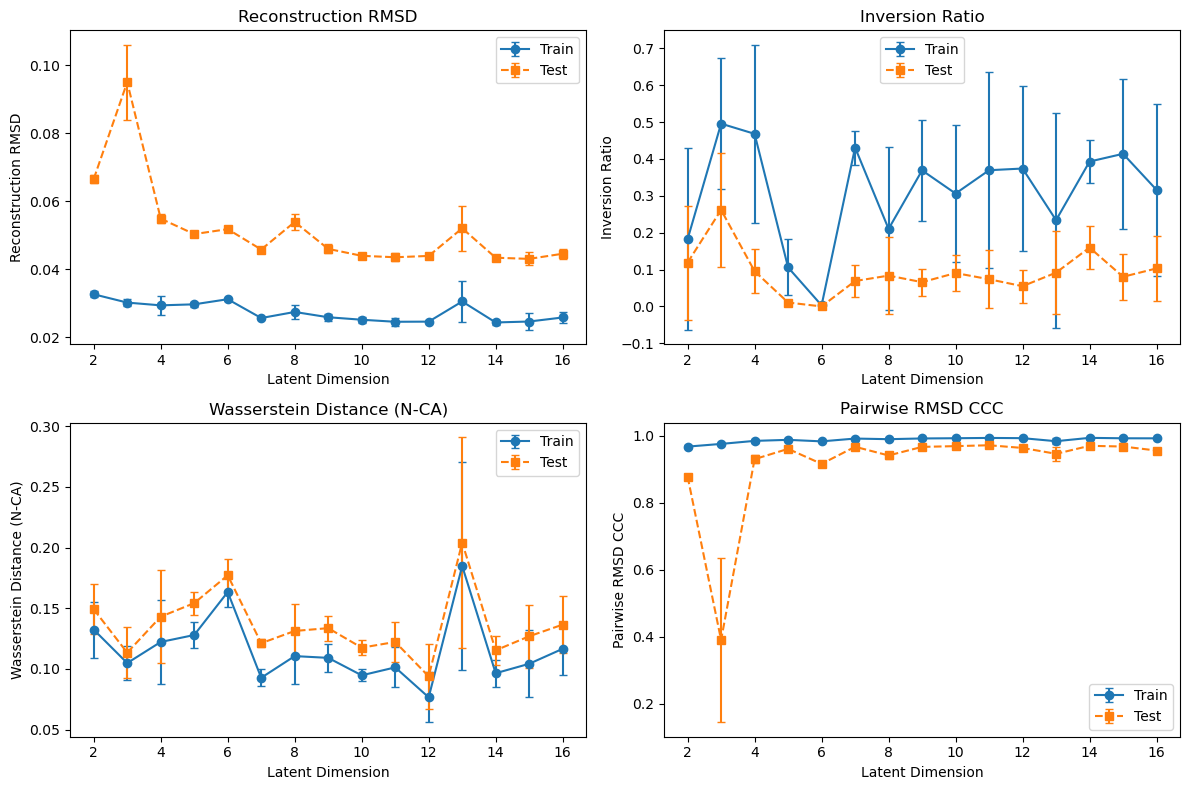

In [14]:
import matplotlib.pyplot as plt

metrics = [
    ("rmsd_mean", "rmsd_std", "Reconstruction RMSD"),
    ("inversion_mean", "inversion_std", "Inversion Ratio"),
    ("wd_mean", "wd_std", "Wasserstein Distance (N-CA)"),
    ("ccc_mean", "ccc_std", "Pairwise RMSD CCC"),
]

df_train = df_all[df_all["dataset"] == "train_both"].copy()
df_test = df_all[df_all["dataset"] == "test_trans"].copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (mean_col, std_col, title) in zip(axes.flat, metrics):
    ax.errorbar(
        df_train["var"],
        df_train[mean_col],
        yerr=df_train[std_col],
        fmt="o-",
        capsize=3,
        label="Train",
    )
    ax.errorbar(
        df_test["var"],
        df_test[mean_col],
        yerr=df_test[std_col],
        fmt="s--",
        capsize=3,
        label="Test",
    )
    ax.set_xlabel("Latent Dimension")
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend()

fig.tight_layout()
plt.show()